# 03. Modelagem e Avaliação

## Objetivo

A pergunta deste notebook é simples de enunciar: qual modelo, combinado com qual representação (PCA, UMAP ou TF-IDF) e qual dimensão, classifica melhor as categorias dos produtos?

## Estrutura deste notebook

1. **O split é carregado do arquivo persistido** pelo notebook 01, garantindo consistência com os demais notebooks.
2. **A validação cruzada (seção 6) usa `sklearn.pipeline.Pipeline`**, refazendo o `fit` do TF-IDF/UMAP a cada fold, evitando que a representação "veja", no ajuste, textos que estão no próprio fold de validação daquela rodada.
3. **Seção 8: teste de significância estatística** entre os dois finalistas, via bootstrap pareado sobre o conjunto de teste, para saber se a diferença de F1-macro entre eles é maior do que se esperaria por ruído de amostragem.
4. **Seção 9: interpretabilidade do modelo vencedor.** Extração dos coeficientes da Logistic Regression sobre o vocabulário do TF-IDF, mostrando quais palavras mais pesam a favor de cada categoria.
5. **PR-AUC complementa o ROC-AUC** na avaliação final, já que o ROC-AUC satura perto de 1 neste problema e comunica pouco além do F1 já reportado.

In [1]:
import sys
import warnings

sys.path.append('./src')

import numpy as np
import pandas as pd
import scipy.sparse as sp

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.dummy import DummyClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score
)

from xgboost import XGBClassifier
import umap

import optuna

from preprocessing import carregar_e_limpar, obter_ou_criar_split
from avaliacao import (
    avaliar_modelo,
    comparar_modelos_bootstrap,
    top_features_por_classe,
    pr_auc_macro,
)

warnings.filterwarnings('ignore')

optuna.logging.set_verbosity(optuna.logging.WARNING)

C:\Users\MarianaCostadeMello\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = carregar_e_limpar('data/raw/dataset_ecommerce.csv')

le = LabelEncoder()
y = le.fit_transform(df['categoria'])

idx_train, idx_test = obter_ou_criar_split(df, y, caminho_split='data/processed/split.npz', test_size=0.2, random_state=42)
y_train, y_test = y[idx_train], y[idx_test]
texto_train = df['texto'].values[idx_train]
texto_test = df['texto'].values[idx_test]

print(f"Treino: {len(idx_train)} | Teste: {len(idx_test)}")

Treino: 22241 | Teste: 5561


## 1. Baseline

Antes de treinar qualquer modelo de verdade, vale estabelecer uma referência simples: prever sempre a classe majoritária. Um modelo só é útil na prática se conseguir superar esse baseline.

In [3]:
baseline_data = np.load('data/processed/embeddings_reducoes/pca_10.npz')
X_tr_base, X_te_base = baseline_data['X_train'], baseline_data['X_test']

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
metricas_baseline, y_pred_dummy = avaliar_modelo(
    'Baseline (classe majoritária)', dummy, X_tr_base, y_train, X_te_base, y_test
)
print("Baseline (prevê sempre a classe majoritária):")
for k, v in metricas_baseline.items():
    if k != 'modelo':
        print(f"  {k}: {v:.3f}")

Baseline (prevê sempre a classe majoritária):
  accuracy: 0.380
  balanced_accuracy: 0.250
  precision_macro: 0.095
  recall_macro: 0.250
  f1_macro: 0.138
  f1_weighted: 0.209


## 2 e 3. Modelos, PCA, UMAP e TF-IDF

Para essa comparação, escolhemos cinco modelos: a Logistic Regression, simples e linear, e quatro modelos baseados em árvores, com naturezas diferentes entre si. Random Forest e Extra Trees são exemplos de bagging, enquanto HistGradientBoosting e XGBoost são exemplos de boosting.

Testamos os cinco modelos com as representações salvas no notebook anterior: PCA e UMAP, cada uma nas três dimensões que definimos (10, 20 e 30), e o TF-IDF, em alta dimensão (5000 palavras, sem nenhuma redução). Uma exceção fica de fora: o HistGradientBoosting não aceita entrada esparsa nesta versão do scikit-learn, então essa combinação específica é pulada.

In [4]:
modelos = {
    'Logistic': LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=2
    ),

    'Extra Trees': ExtraTreesClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=2
    ),

    'HistGradientBoosting': HistGradientBoostingClassifier(
        random_state=42
    ),

    'XGBoost': XGBClassifier(
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=2
    )
}

reducoes_disponiveis = {
    'PCA': [10, 20, 30],
    'UMAP': [10, 20, 30],
    'TF-IDF': [5000]
}

resultados = []
predicoes_cache = {}
embeddings_cache = {}

for reducao, dims in reducoes_disponiveis.items():

    for dim in dims:

        if reducao == 'TF-IDF':
            X_tr = sp.load_npz('data/processed/embeddings_reducoes/tfidf_train.npz')
            X_te = sp.load_npz('data/processed/embeddings_reducoes/tfidf_test.npz')
        else:
            dados = np.load(
                f'data/processed/embeddings_reducoes/'
                f'{reducao.lower()}_{dim}.npz'
            )
            X_tr = dados['X_train']
            X_te = dados['X_test']

        embeddings_cache[(reducao, dim)] = (X_tr, X_te)

        for nome, modelo in modelos.items():

            if reducao == 'TF-IDF' and nome == 'HistGradientBoosting':
                print("[AVISO] HistGradientBoosting pulado para TF-IDF (não suporta entrada esparsa).")
                continue

            metricas, y_pred = avaliar_modelo(
                nome,
                modelo,
                X_tr,
                y_train,
                X_te,
                y_test
            )

            metricas.update({
                'reducao': reducao,
                'dim': dim
            })

            resultados.append(metricas)

            predicoes_cache[
                (reducao, dim, nome)
            ] = y_pred

[AVISO] HistGradientBoosting pulado para TF-IDF (não suporta entrada esparsa).


## Tabela comparativa

In [5]:
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados[['reducao', 'dim', 'modelo', 'accuracy', 'precision_macro',
                                'recall_macro', 'f1_macro', 'f1_weighted', 'balanced_accuracy']]
df_resultados = df_resultados.sort_values('f1_macro', ascending=False).reset_index(drop=True)
df_resultados

,reducao,dim,modelo,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,balanced_accuracy
0,TF-IDF,5000,Logistic,0.947671,0.950858,0.944112,0.947321,0.947598,0.944112
1,UMAP,20,Random Forest,0.938680,0.940091,0.937675,0.938536,0.938605,0.937675
2,UMAP,20,Extra Trees,0.938320,0.939225,0.937662,0.938072,0.938237,0.937662
3,UMAP,30,Random Forest,0.937961,0.938914,0.936952,0.937591,0.937876,0.936952
4,UMAP,10,Extra Trees,0.937601,0.938669,0.936898,0.937475,0.937524,0.936898
5,UMAP,10,HistGradientBoosting,0.937781,0.938911,0.936518,0.937358,0.937716,0.936518
6,UMAP,10,Random Forest,0.937601,0.938497,0.936634,0.937204,0.937538,0.936634
7,UMAP,30,XGBoost,0.937421,0.938732,0.936220,0.937184,0.937364,0.936220
8,UMAP,20,XGBoost,0.937421,0.938225,0.936520,0.937019,0.937383,0.936520
9,UMAP,20,HistGradientBoosting,0.936522,0.937520,0.935893,0.936406,0.936478,0.935893


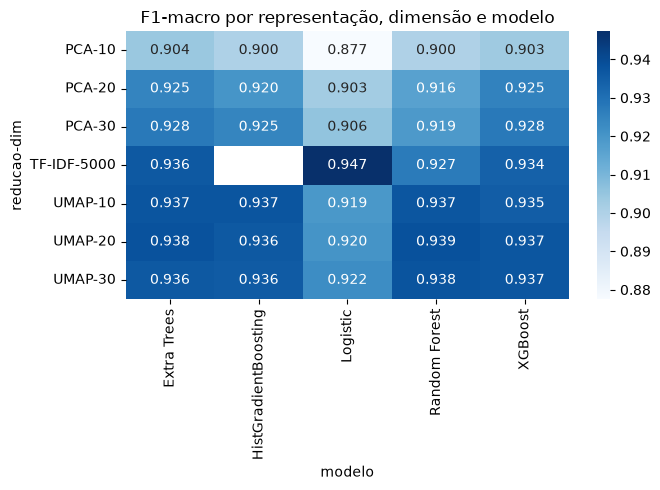

Melhor combinação geral: TF-IDF 5000D + Logistic (F1-macro=0.947)
Ganho sobre o baseline: 0.810 em F1-macro


In [6]:
pivot = df_resultados.pivot_table(index=['reducao', 'dim'], columns='modelo', values='f1_macro')
plt.figure(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='Blues')
plt.title('F1-macro por representação, dimensão e modelo')
plt.tight_layout()
plt.savefig('figs/03_heatmap_f1_macro.png', dpi=100)
plt.show()

melhor = df_resultados.iloc[0]
melhor_reducao, melhor_dim, melhor_modelo = melhor['reducao'], int(melhor['dim']), melhor['modelo']
print(f"Melhor combinação geral: {melhor_reducao} {melhor_dim}D + {melhor_modelo} (F1-macro={melhor['f1_macro']:.3f})")
print(f"Ganho sobre o baseline: {melhor['f1_macro'] - metricas_baseline['f1_macro']:.3f} em F1-macro")

## 4. Escolhendo as configurações para otimizar

A decisão de otimizar o XGBoost com Optuna foi uma escolha do projeto, não uma exigência do case. Faz sentido então otimizar também o candidato que teve o melhor resultado geral na tabela acima, TF-IDF + Logistic Regression, para comparar os dois em pé de igualdade e deixar o notebook final usar quem realmente vencer, e não quem foi escolhido antes de rodar a comparação.

In [7]:
resultados_xgb = df_resultados[df_resultados['modelo'] == 'XGBoost'].sort_values('f1_macro', ascending=False)
melhor_xgb = resultados_xgb.iloc[0]
xgb_reducao, xgb_dim = melhor_xgb['reducao'], int(melhor_xgb['dim'])
print(f"Melhor configuração para XGBoost: {xgb_reducao} {xgb_dim}D (F1-macro={melhor_xgb['f1_macro']:.3f})")

X_tr_xgb, X_te_xgb = embeddings_cache[(xgb_reducao, xgb_dim)]

resultados_log = df_resultados[df_resultados['modelo'] == 'Logistic'].sort_values('f1_macro', ascending=False)
melhor_log = resultados_log.iloc[0]
log_reducao, log_dim = melhor_log['reducao'], int(melhor_log['dim'])
print(f"Melhor configuração para Logistic Regression: {log_reducao} {log_dim}D (F1-macro={melhor_log['f1_macro']:.3f})")

X_tr_log, X_te_log = embeddings_cache[(log_reducao, log_dim)]

Melhor configuração para XGBoost: UMAP 30D (F1-macro=0.937)
Melhor configuração para Logistic Regression: TF-IDF 5000D (F1-macro=0.947)


## 5. Otimização com Optuna

Para não usar o conjunto de teste durante a busca de hiperparâmetros, o que seria um vazamento de dados, separamos uma fatia de validação dentro do próprio treino. Os mesmos índices de treino/validação são usados para os dois modelos, então a comparação entre eles fica justa.

In [8]:
idx_tr_train, idx_tr_val = train_test_split(
    np.arange(len(y_train)), test_size=0.2, random_state=42, stratify=y_train
)
y_opt_train, y_opt_val = y_train[idx_tr_train], y_train[idx_tr_val]

X_opt_train_xgb, X_opt_val_xgb = X_tr_xgb[idx_tr_train], X_tr_xgb[idx_tr_val]
X_opt_train_log, X_opt_val_log = X_tr_log[idx_tr_train], X_tr_log[idx_tr_val]

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'eval_metric': 'mlogloss', 'random_state': 42, 'n_jobs': 2,
    }
    modelo = XGBClassifier(**params)
    modelo.fit(X_opt_train_xgb, y_opt_train)
    y_pred = modelo.predict(X_opt_val_xgb)
    return f1_score(y_opt_val, y_pred, average='macro')

study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=25)

melhores_params_xgb = study_xgb.best_params.copy()
melhores_params_xgb.update({'eval_metric': 'mlogloss', 'random_state': 42, 'n_jobs': 2})

print(f"[XGBoost] Configuração: {xgb_reducao} {xgb_dim}D")
print(f"[XGBoost] Melhor F1-macro (validação): {study_xgb.best_value:.3f}")
print(f"[XGBoost] Melhores hiperparâmetros: {study_xgb.best_params}")


def objective_logistic(trial):
    params = {
        'C': trial.suggest_float('C', 1e-3, 1e2, log=True),
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
        'max_iter': 2000,
        'random_state': 42,
    }
    modelo = LogisticRegression(**params)
    modelo.fit(X_opt_train_log, y_opt_train)
    y_pred = modelo.predict(X_opt_val_log)
    return f1_score(y_opt_val, y_pred, average='macro')

study_log = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_log.optimize(objective_logistic, n_trials=25)

melhores_params_log = study_log.best_params.copy()
melhores_params_log.update({'max_iter': 2000, 'random_state': 42})

print(f"\n[Logistic] Configuração: {log_reducao} {log_dim}D")
print(f"[Logistic] Melhor F1-macro (validação): {study_log.best_value:.3f}")
print(f"[Logistic] Melhores hiperparâmetros: {study_log.best_params}")

[XGBoost] Configuração: UMAP 30D
[XGBoost] Melhor F1-macro (validação): 0.950
[XGBoost] Melhores hiperparâmetros: {'n_estimators': 300, 'max_depth': 9, 'learning_rate': 0.13682416728795893, 'subsample': 0.7123588498882463, 'colsample_bytree': 0.6823606111958546, 'min_child_weight': 2}

[Logistic] Configuração: TF-IDF 5000D
[Logistic] Melhor F1-macro (validação): 0.952
[Logistic] Melhores hiperparâmetros: {'C': 1.744778701210229, 'class_weight': 'balanced'}


## 6. Validação cruzada (5-fold), sem vazamento

Passar `X_tr_xgb`/`X_tr_log` já reduzidos (TF-IDF/UMAP ajustados uma única vez no treino completo) para o `cross_validate` seria um erro sutil: em cada fold, a representação já teria "visto" os textos do próprio fold de validação durante o ajuste. Isso infla artificialmente a estabilidade aparente entre folds.

Por isso, cada finalista vira um `Pipeline` (representação + modelo), e é esse pipeline que entra no `cross_validate` recebendo os dados **crus** (texto para o TF-IDF, embeddings densos para o UMAP). Isso garante que o `fit` da representação aconteça de novo a cada fold, só com os dados de treino daquele fold, exatamente como aconteceria com dados novos em produção.

In [9]:
scoring = {'f1_macro': 'f1_macro', 'accuracy': 'accuracy', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Pipeline do finalista Logistic + TF-IDF: refit do TfidfVectorizer a cada fold ---
pipeline_log = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, min_df=2)),
    ('clf', LogisticRegression(**melhores_params_log)),
])
scores_cv_log = cross_validate(pipeline_log, texto_train, y_train, cv=skf, scoring=scoring)

# --- Pipeline do finalista XGBoost + UMAP: refit do UMAP a cada fold ---
embeddings_completos = np.load('data/raw/embeddings_texto.npy')
from preprocessing import carregar_embeddings_alinhados
embeddings_alinhados = carregar_embeddings_alinhados('data/raw/embeddings_texto.npy', df)
emb_train_bruto = embeddings_alinhados[idx_train]

pipeline_xgb = Pipeline([
    ('umap', umap.UMAP(n_components=xgb_dim, n_jobs=2)),
    ('clf', XGBClassifier(**melhores_params_xgb)),
])
scores_cv_xgb = cross_validate(pipeline_xgb, emb_train_bruto, y_train, cv=skf, scoring=scoring)

print(f"5-fold CV, XGBoost otimizado ({xgb_reducao} {xgb_dim}D), pipeline refeito a cada fold:")
for metrica in scoring:
    vals = scores_cv_xgb[f'test_{metrica}']
    print(f"  {metrica:16s} média={vals.mean():.3f} +/- {vals.std():.3f} | valores={np.round(vals, 3)}")

print(f"\n5-fold CV, Logistic Regression otimizada ({log_reducao} {log_dim}D), pipeline refeito a cada fold:")
for metrica in scoring:
    vals = scores_cv_log[f'test_{metrica}']
    print(f"  {metrica:16s} média={vals.mean():.3f} +/- {vals.std():.3f} | valores={np.round(vals, 3)}")

dados_cv_xgb = pd.DataFrame({m: scores_cv_xgb[f'test_{m}'] for m in scoring})
dados_cv_xgb['modelo'] = 'XGBoost'
dados_cv_log = pd.DataFrame({m: scores_cv_log[f'test_{m}'] for m in scoring})
dados_cv_log['modelo'] = 'Logistic Regression'
dados_cv = pd.concat([dados_cv_xgb, dados_cv_log], ignore_index=True)
dados_cv_long = dados_cv.melt(id_vars='modelo', var_name='metrica', value_name='score')

plt.figure(figsize=(9, 5))
sns.boxplot(data=dados_cv_long, x='metrica', y='score', hue='modelo')
sns.stripplot(data=dados_cv_long, x='metrica', y='score', hue='modelo', dodge=True, color='black', alpha=0.5, legend=False)
plt.title('Estabilidade das métricas entre folds (5-fold CV, sem vazamento), os dois finalistas')
plt.ylabel('Score')
plt.tight_layout()
plt.savefig('figs/03_cv_estabilidade.png', dpi=100)
plt.show()

TypeError: only integer scalar arrays can be converted to a scalar index

## 7. Avaliação final no teste

Os dois finalistas otimizados são treinados no treino completo e avaliados no teste. O que tiver o maior F1-macro no teste é o vencedor, e é essa configuração que segue para as análises abaixo e para o notebook final.

XGBoost otimizado   (UMAP 20D), F1 macro: 0.938 | F1 weighted: 0.939 | ROC-AUC: 0.986 | PR-AUC macro: 0.967
Logistic otimizada  (TF-IDF 5000D), F1 macro: 0.949 | F1 weighted: 0.950 | ROC-AUC: 0.991 | PR-AUC macro: 0.978

[Nota] O ROC-AUC dos dois modelos está muito perto de 1 e diferencia pouco entre eles. Isso é esperado num problema com boa separação entre classes como este. O PR-AUC por classe é reportado ao lado por ser mais sensível ao desbalanceamento residual entre categorias.

Vencedor: Logistic Regression (TF-IDF 5000D), F1-macro=0.949

                      precision    recall  f1-score   support

               Books       0.94      0.93      0.94      1251
Clothing_Accessories       0.97      0.98      0.98      1135
         Electronics       0.93      0.93      0.93      1062
           Household       0.95      0.95      0.95      2113

            accuracy                           0.95      5561
           macro avg       0.95      0.95      0.95      5561
        weig

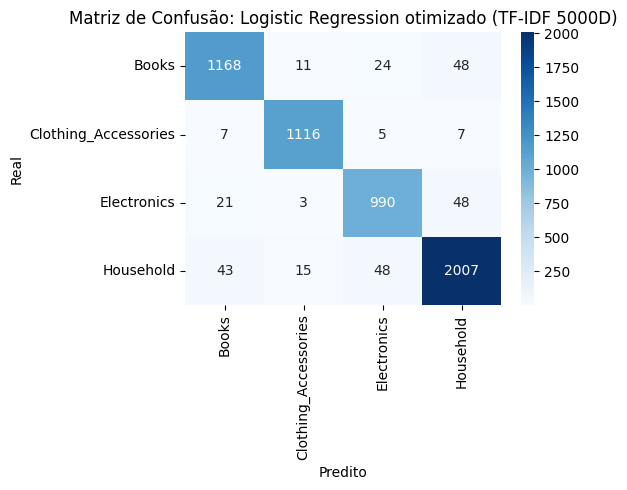

In [ ]:
xgb_final = XGBClassifier(**melhores_params_xgb)
xgb_final.fit(X_tr_xgb, y_train)
y_pred_xgb = xgb_final.predict(X_te_xgb)
y_proba_xgb = xgb_final.predict_proba(X_te_xgb)

f1_macro_xgb = f1_score(y_test, y_pred_xgb, average='macro')
f1_weighted_xgb = f1_score(y_test, y_pred_xgb, average='weighted')
roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb, multi_class='ovr', average='macro')
pr_auc_xgb = pr_auc_macro(y_test, y_proba_xgb, le.classes_)

log_final = LogisticRegression(**melhores_params_log)
log_final.fit(X_tr_log, y_train)
y_pred_log = log_final.predict(X_te_log)
y_proba_log = log_final.predict_proba(X_te_log)

f1_macro_log = f1_score(y_test, y_pred_log, average='macro')
f1_weighted_log = f1_score(y_test, y_pred_log, average='weighted')
roc_auc_log = roc_auc_score(y_test, y_proba_log, multi_class='ovr', average='macro')
pr_auc_log = pr_auc_macro(y_test, y_proba_log, le.classes_)

print(f"XGBoost otimizado   ({xgb_reducao} {xgb_dim}D), F1 macro: {f1_macro_xgb:.3f} | F1 weighted: {f1_weighted_xgb:.3f} | ROC-AUC: {roc_auc_xgb:.3f} | PR-AUC macro: {pr_auc_xgb['macro']:.3f}")
print(f"Logistic otimizada  ({log_reducao} {log_dim}D), F1 macro: {f1_macro_log:.3f} | F1 weighted: {f1_weighted_log:.3f} | ROC-AUC: {roc_auc_log:.3f} | PR-AUC macro: {pr_auc_log['macro']:.3f}")
print("\n[Nota] O ROC-AUC dos dois modelos está muito perto de 1 e diferencia pouco entre eles. "
      "Isso é esperado num problema com boa separação entre classes como este. O PR-AUC por classe é "
      "reportado ao lado por ser mais sensível ao desbalanceamento residual entre categorias.")

if f1_macro_xgb >= f1_macro_log:
    modelo_final_nome = 'XGBoost'
    reducao_final, dim_final = xgb_reducao, xgb_dim
    params_finais = melhores_params_xgb
    y_pred_final, y_proba_final = y_pred_xgb, y_proba_xgb
    f1_macro_final, f1_weighted_final, roc_auc_final = f1_macro_xgb, f1_weighted_xgb, roc_auc_xgb
else:
    modelo_final_nome = 'Logistic Regression'
    reducao_final, dim_final = log_reducao, log_dim
    params_finais = melhores_params_log
    y_pred_final, y_proba_final = y_pred_log, y_proba_log
    f1_macro_final, f1_weighted_final, roc_auc_final = f1_macro_log, f1_weighted_log, roc_auc_log

print(f"\nVencedor: {modelo_final_nome} ({reducao_final} {dim_final}D), F1-macro={f1_macro_final:.3f}")

print()
print(classification_report(y_test, y_pred_final, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Matriz de Confusão: {modelo_final_nome} otimizado ({reducao_final} {dim_final}D)')
plt.ylabel('Real')
plt.xlabel('Predito')
plt.tight_layout()
plt.savefig('figs/03_matriz_confusao.png', dpi=100)
plt.show()

## 8. A diferença entre os dois finalistas é estatisticamente significativa?

A diferença de F1-macro entre os dois finalistas é pequena. Em vez de só comparar os dois números, testamos com bootstrap pareado sobre o conjunto de teste: reamostramos os mesmos índices de teste muitas vezes, recalculamos a métrica dos dois modelos em cada reamostragem e vemos se a diferença observada é maior do que se esperaria por ruído de amostragem.

In [ ]:
resultado_significancia = comparar_modelos_bootstrap(
    y_test, y_pred_log, y_pred_xgb, metrica='f1_macro', n_boot=3000, random_state=42
)
print(f"Diferença observada (Logistic − XGBoost) em F1-macro: {resultado_significancia['diferenca_observada']:+.4f}")
print(f"Intervalo de confiança 95% (bootstrap): [{resultado_significancia['ic_95_baixo']:+.4f}, {resultado_significancia['ic_95_alto']:+.4f}]")
print(f"p-valor (duas caudas): {resultado_significancia['p_valor']:.4f}")
if resultado_significancia['significativo_5pct']:
    print("=> A diferença é estatisticamente significativa ao nível de 5%: não é razoável atribuí-la "
          "só a ruído de amostragem no conjunto de teste.")
else:
    print("=> A diferença NÃO é estatisticamente significativa ao nível de 5%: com esse tamanho de "
          "teste, não dá para descartar que o resultado seja ruído de amostragem, e os dois modelos "
          "deveriam ser considerados estatisticamente equivalentes nesta métrica.")

Diferença observada (Logistic − XGBoost) em F1-macro: +0.0113
Intervalo de confiança 95% (bootstrap): [+0.0056, +0.0171]
p-valor (duas caudas): 0.0007
=> A diferença é estatisticamente significativa ao nível de 5%: não é razoável atribuí-la só a ruído de amostragem no conjunto de teste.


## 9. Interpretabilidade do modelo vencedor

Não basta saber que o modelo classifica bem. Vale abrir o modelo vencedor para ver quais palavras ele está de fato usando para decidir. Se o vencedor for a Logistic Regression sobre TF-IDF, extraímos os coeficientes por classe: cada coeficiente é o peso daquela palavra na decisão daquela categoria especificamente (não é uma relação causal, é a direção e a força com que a presença da palavra desloca a previsão do modelo).

In [ ]:
if modelo_final_nome == 'Logistic Regression':
    tfidf_final_vectorizer = TfidfVectorizer(max_features=5000, min_df=2)
    tfidf_final_vectorizer.fit(texto_train)  # mesmo vocabulário usado para treinar log_final

    top_palavras = top_features_por_classe(log_final, tfidf_final_vectorizer, le.classes_, top_n=12)
    for classe, dados_classe in top_palavras.items():
        print(f"\n=== {classe} ===")
        print("Palavras a favor (maior coeficiente positivo):")
        for palavra, peso in dados_classe['a_favor']:
            print(f"    {palavra:20s} {peso:+.3f}")
else:
    print(f"O vencedor desta execução foi {modelo_final_nome}, não a Logistic Regression. "
          "A extração de coeficientes por palavra só se aplica a um modelo linear sobre TF-IDF. "
          "Para interpretar um XGBoost, o caminho seria feature importance por ganho (gain) ou SHAP, "
          "não implementado nesta seção.")


=== Books ===
Palavras a favor (maior coeficiente positivo):
    book                 +5.314
    fishing              +4.516
    author               +4.335
    guide                +3.558
    game                 +3.443
    action               +3.386
    how                  +3.204
    training             +3.044
    education            +3.025
    oxford               +3.007
    pool                 +2.983
    family               +2.958

=== Clothing_Accessories ===
Palavras a favor (maior coeficiente positivo):
    women                +7.575
    men                  +7.192
    sunglasses           +6.751
    boys                 +6.016
    cotton               +5.976
    girls                +5.894
    bra                  +5.443
    socks                +4.418
    jacket               +4.314
    unisex               +4.291
    boy                  +4.019
    wear                 +3.935

=== Electronics ===
Palavras a favor (maior coeficiente positivo):
    laptop               

## 10. Análise dos erros

In [ ]:
erros = pd.DataFrame({
    'texto': [t[:120] for t in texto_test],
    'categoria_real': le.inverse_transform(y_test),
    'categoria_prevista': le.inverse_transform(y_pred_final),
})
erros_apenas = erros[erros['categoria_real'] != erros['categoria_prevista']]
print(f"Total de erros: {len(erros_apenas)} de {len(erros)} ({len(erros_apenas) / len(erros) * 100:.1f}%)")
display(erros_apenas.sample(min(10, len(erros_apenas)), random_state=42))

Total de erros: 280 de 5561 (5.0%)


,texto,categoria_real,categoria_prevista
654,SR Global Spy Hd Pen Camera with Voice-Video R...,Electronics,Household
1936,RRG Cotton Durry/Durrie/Rug Block Print (4X6 F...,Household,Clothing_Accessories
4831,WISSEN Wooden Transportation knob Puzzle Tray ...,Books,Household
5125,Candlestick Accent Light in Blackened Tin Cand...,Household,Books
2767,Kauberi Jewels 12pcs Bridal Wedding Prom Silve...,Household,Clothing_Accessories
279,INSPIRED : HOW TO CREATE TECH PRODUCTS CUSTOME...,Books,Household
2686,"Tool Point Silicon Waves Analogue Circuit AC, ...",Household,Electronics
3875,Charms Anklet for Women (Silver)(CR0251-285ef)...,Household,Clothing_Accessories
2627,Hoover Genuine Purepower Dustmanager Whirlwind...,Household,Books
2785,DOCOSS Waterproof Cree Bright Zoom LED Torches...,Household,Electronics


In [ ]:
pares_confusao = (
    erros_apenas.groupby(['categoria_real', 'categoria_prevista'])
    .size()
    .reset_index(name='quantidade')
    .sort_values('quantidade', ascending=False)
)
print("Pares de categorias mais confundidos:")
display(pares_confusao.head(10))

Pares de categorias mais confundidos:


,categoria_real,categoria_prevista,quantidade
2,Books,Household,48
11,Household,Electronics,48
8,Electronics,Household,48
9,Household,Books,43
1,Books,Electronics,24
6,Electronics,Books,21
10,Household,Clothing_Accessories,15
0,Books,Clothing_Accessories,11
3,Clothing_Accessories,Books,7
5,Clothing_Accessories,Household,7


## Fechamento

Com os dois finalistas otimizados por Optuna, o vencedor (ver seção 7) segue para o notebook final, `04_modelo_final_conclusao.ipynb`.

A validação cruzada agora é feita sem vazamento (seção 6), o teste de significância (seção 8) qualifica se a diferença entre os dois finalistas é real ou pode ser ruído de amostragem, e a interpretabilidade (seção 9) mostra concretamente quais palavras o modelo vencedor está usando, em vez de deixar isso como hipótese.